# Random Forest Classification and Feature Importance Tutorial

**Technique:** Random Forest Classification  
**Dataset:** Breast Cancer Wisconsin dataset from `sklearn.datasets.load_breast_cancer()`  
**Tutorial focus:** Train a Random Forest classifier, evaluate its performance, and explain model decisions using feature importance.

## Learning goals

By the end of this notebook, learners should be able to:

1. Explain how a Random Forest combines many decision trees.
2. Load and prepare a built-in scikit-learn classification dataset.
3. Train a `RandomForestClassifier`.
4. Evaluate classification performance using accuracy, confusion matrix, classification report, and ROC curve.
5. Interpret impurity-based and permutation-based feature importance.
6. Reuse the workflow on their own classification datasets.

## Figure roadmap

This notebook covers the figures chronologically:

- **Figure 1:** Class distribution bar chart  
- **Figure 2:** Shallow decision tree  
- **Figure 3:** Random Forest workflow diagram  
- **Figure 4:** Majority voting diagram  
- **Figure 5:** Train-test pipeline  
- **Figure 6:** Confusion matrix heatmap  
- **Figure 7:** ROC curve  
- **Figure 8:** Top 10 feature importance bar chart  
- **Figure 9:** Permutation importance chart  


## 1. Import libraries

This notebook uses standard scientific Python tools plus scikit-learn. All figures are made with Matplotlib so the notebook remains simple and portable.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

## 2. Load the dataset

The Breast Cancer Wisconsin dataset is a binary classification dataset. Each sample describes features computed from a digitized image of a breast mass. The target has two classes:

- `0 = malignant`
- `1 = benign`

The task is to predict whether a tumor sample is malignant or benign using numeric features.


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

target_names = dict(enumerate(data.target_names))
target_names_title = {0: "Malignant", 1: "Benign"}

print("Dataset shape:", X.shape)
print("Target names:", target_names)
X.head()

Dataset shape: (569, 30)
Target names: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Figure 1: Class distribution bar chart

This figure shows whether the two target classes are balanced. Class balance matters because a model can appear accurate if it mostly predicts the majority class.


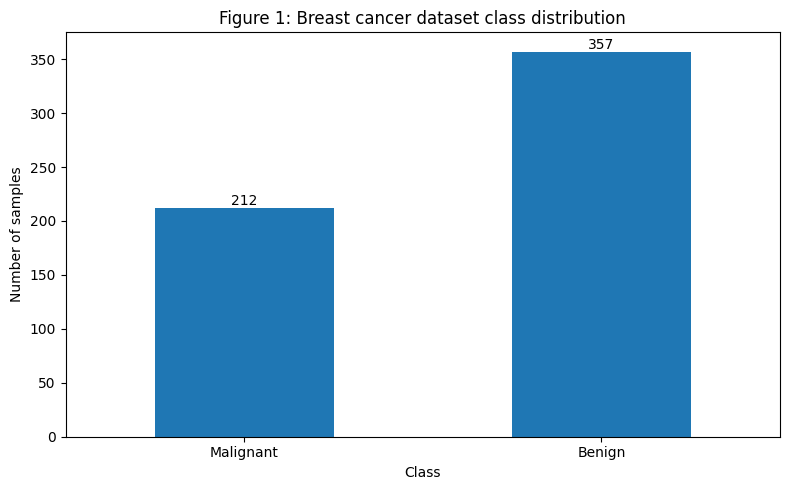

,count
target,
Malignant,212
Benign,357


In [3]:
class_counts = y.map(target_names_title).value_counts().reindex(["Malignant", "Benign"])

fig, ax = plt.subplots()
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Figure 1: Breast cancer dataset class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

class_counts

## 3. Create a train-test split

A train-test split allows us to train the model on one part of the data and evaluate it on unseen data. Stratification keeps the class proportions similar in both sets.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class counts:")
print(y_train.map(target_names_title).value_counts())
print("\nTesting class counts:")
print(y_test.map(target_names_title).value_counts())

Training set: (426, 30)
Testing set: (143, 30)

Training class counts:
target
Benign       267
Malignant    159
Name: count, dtype: int64

Testing class counts:
target
Benign       90
Malignant    53
Name: count, dtype: int64


## Figure 2: Shallow decision tree

A Random Forest is made of many decision trees. Before studying the forest, it helps to understand one small tree. This shallow tree shows how a model makes decisions by splitting samples based on feature values.


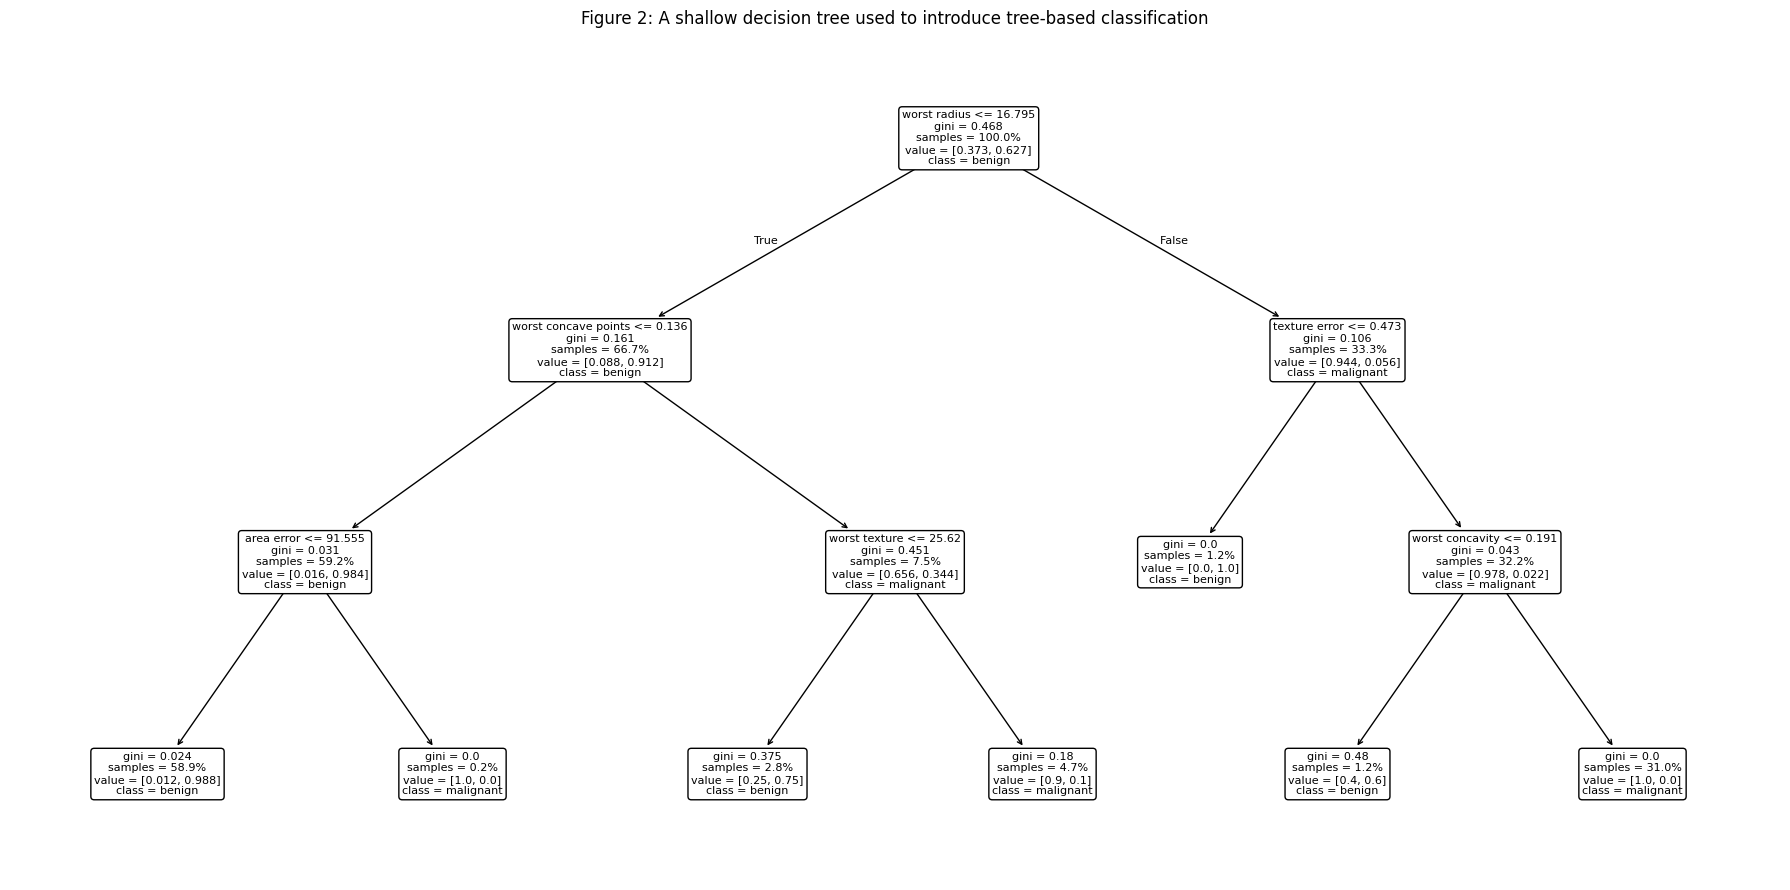

In [5]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
shallow_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    shallow_tree,
    feature_names=list(X.columns),
    class_names=list(data.target_names),
    filled=False,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Figure 2: A shallow decision tree used to introduce tree-based classification")
plt.tight_layout()
plt.show()

## Figure 3: Random Forest workflow diagram

A Random Forest improves on a single tree by creating many different trees. Each tree sees a bootstrap sample of the training data and considers random subsets of features when splitting nodes. The final prediction is made by combining tree predictions.


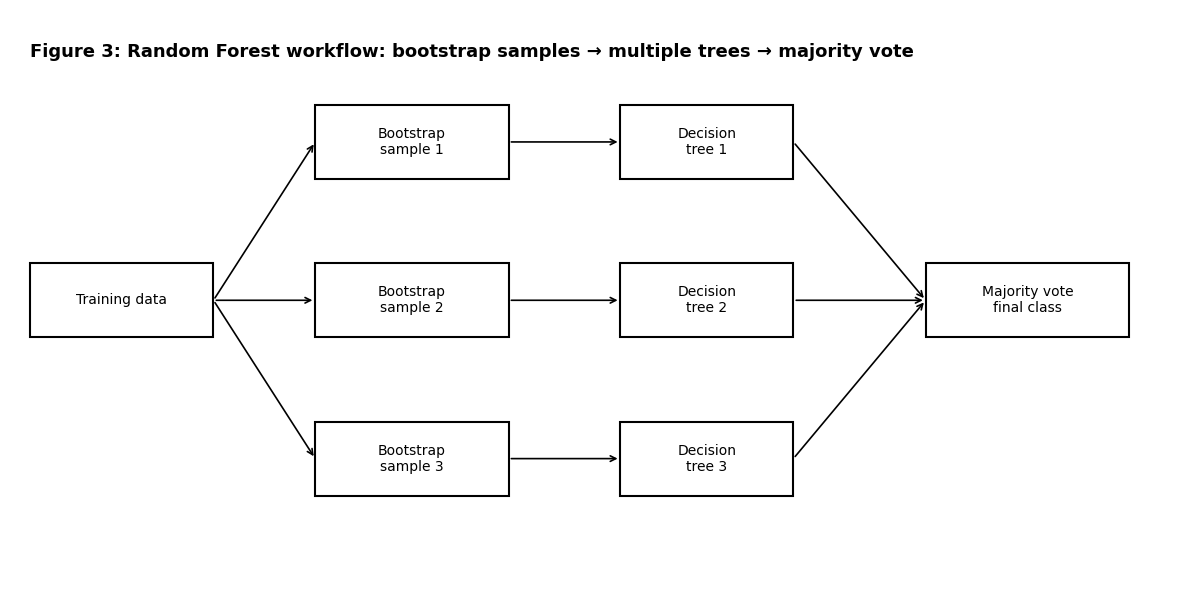

In [6]:
def add_box(ax, xy, text, width=1.8, height=0.6):
    x, y = xy
    rect = plt.Rectangle((x, y), width, height, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", wrap=True)
    return rect

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()

add_box(ax, (0.2, 2.5), "Training data", 1.8, 0.7)

sample_positions = [(3.0, 4.0), (3.0, 2.5), (3.0, 1.0)]
tree_positions = [(6.0, 4.0), (6.0, 2.5), (6.0, 1.0)]

for i, pos in enumerate(sample_positions, start=1):
    add_box(ax, pos, f"Bootstrap\nsample {i}", 1.9, 0.7)
    ax.annotate("", xy=(pos[0], pos[1] + 0.35), xytext=(2.0, 2.85),
                arrowprops=dict(arrowstyle="->", linewidth=1.2))

for i, (sample_pos, tree_pos) in enumerate(zip(sample_positions, tree_positions), start=1):
    add_box(ax, tree_pos, f"Decision\ntree {i}", 1.7, 0.7)
    ax.annotate("", xy=(tree_pos[0], tree_pos[1] + 0.35),
                xytext=(sample_pos[0] + 1.9, sample_pos[1] + 0.35),
                arrowprops=dict(arrowstyle="->", linewidth=1.2))

add_box(ax, (9.0, 2.5), "Majority vote\nfinal class", 2.0, 0.7)

for tree_pos in tree_positions:
    ax.annotate("", xy=(9.0, 2.85), xytext=(tree_pos[0] + 1.7, tree_pos[1] + 0.35),
                arrowprops=dict(arrowstyle="->", linewidth=1.2))

ax.text(0.2, 5.15, "Figure 3: Random Forest workflow: bootstrap samples → multiple trees → majority vote",
        fontsize=13, weight="bold")
ax.set_xlim(0, 11.5)
ax.set_ylim(0.2, 5.6)
plt.tight_layout()
plt.show()

## 4. Train the Random Forest classifier

The model below uses 200 trees. More trees often make the forest more stable, although training becomes slower. The random seed makes the results reproducible.


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"Test accuracy: {accuracy:.3f}")
print(f"ROC AUC score: {auc_score:.3f}")

Test accuracy: 0.958
ROC AUC score: 0.995


## Figure 4: Majority voting diagram

Each tree in a Random Forest gives a prediction. For classification, the forest chooses the class with the most votes. The example below takes one test sample and shows the predictions from the first nine trees.


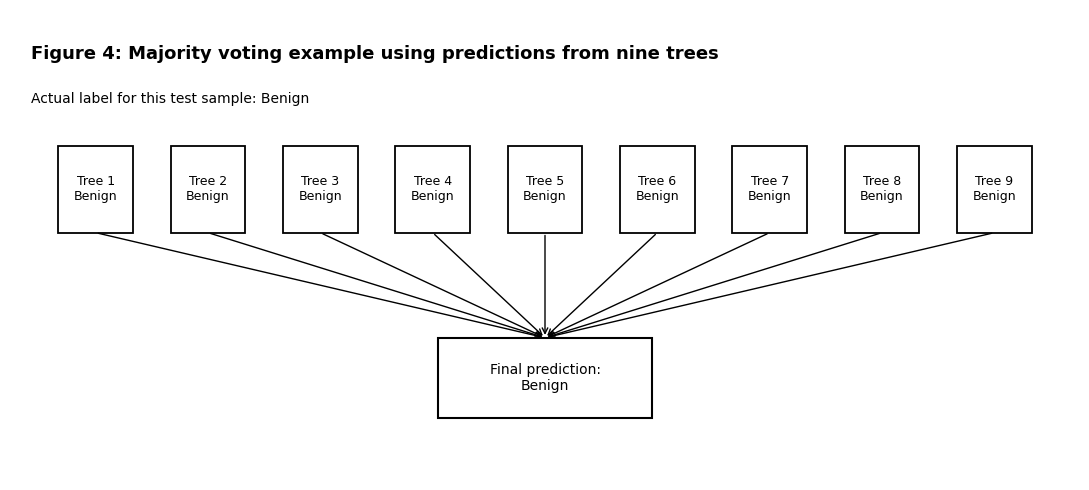

,Tree votes
Benign,9


In [8]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
actual_label = target_names_title[int(y_test.iloc[sample_index])]

tree_votes = []
for tree in rf_model.estimators_[:9]:
    # Convert to values to avoid feature name warning from individual trees
    vote = int(tree.predict(sample.values)[0])
    tree_votes.append(vote)

vote_labels = [target_names_title[vote] for vote in tree_votes]
final_prediction = target_names_title[int(rf_model.predict(sample)[0])]

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_axis_off()

x_positions = np.linspace(0.8, 9.2, 9)
for i, (x_pos, vote_label) in enumerate(zip(x_positions, vote_labels), start=1):
    rect = plt.Rectangle((x_pos - 0.35, 2.2), 0.7, 0.7, fill=False, linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x_pos, 2.55, f"Tree {i}\n{vote_label}", ha="center", va="center", fontsize=9)
    ax.annotate("", xy=(5.0, 1.35), xytext=(x_pos, 2.2),
                arrowprops=dict(arrowstyle="->", linewidth=1.0))

final_rect = plt.Rectangle((4.0, 0.7), 2.0, 0.65, fill=False, linewidth=1.5)
ax.add_patch(final_rect)
ax.text(5.0, 1.025, f"Final prediction:\n{final_prediction}", ha="center", va="center", fontsize=10)

ax.text(0.2, 3.6, "Figure 4: Majority voting example using predictions from nine trees",
        fontsize=13, weight="bold")
ax.text(0.2, 3.25, f"Actual label for this test sample: {actual_label}")
ax.set_xlim(0, 10)
ax.set_ylim(0.2, 4.0)
plt.tight_layout()
plt.show()

pd.Series(vote_labels).value_counts().rename("Tree votes")

## Figure 5: Train-test pipeline

This diagram summarizes the practical workflow used in this notebook. The same workflow can be reused for many supervised classification problems.


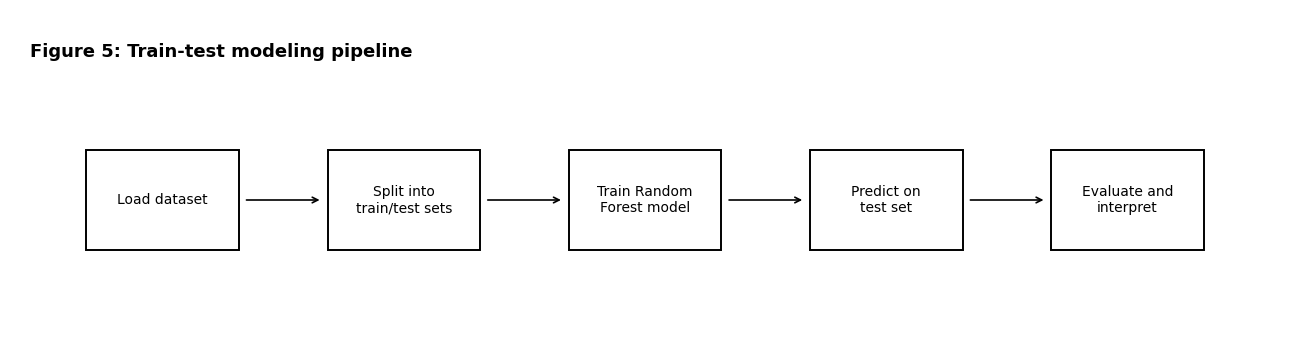

In [13]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_axis_off()

pipeline_steps = [
    "Load dataset",
    "Split into\ntrain/test sets",
    "Train Random\nForest model",
    "Predict on\ntest set",
    "Evaluate and\ninterpret"
]

# Shifted start and end points to the right (from 0.5-10.0 to 1.5-11.0)
x_positions = np.linspace(1.5, 11, len(pipeline_steps))

for i, (x_pos, step) in enumerate(zip(x_positions, pipeline_steps)):
    rect = plt.Rectangle((x_pos - 0.75, 1.4), 1.5, 0.75, fill=False, linewidth=1.4)
    ax.add_patch(rect)
    ax.text(x_pos, 1.775, step, ha="center", va="center")
    if i < len(pipeline_steps) - 1:
        ax.annotate("", xy=(x_positions[i+1] - 0.8, 1.775), xytext=(x_pos + 0.8, 1.775),
                    arrowprops=dict(arrowstyle="->", linewidth=1.2))

ax.text(0.2, 2.85, "Figure 5: Train-test modeling pipeline", fontsize=13, weight="bold")
ax.set_xlim(0, 12.5)
ax.set_ylim(0.8, 3.2)
plt.tight_layout()
plt.show()

## 5. Classification report

The classification report gives precision, recall, and F1-score for each class.

- **Precision:** Of the samples predicted as a class, how many were correct?
- **Recall:** Of the actual samples in a class, how many did the model find?
- **F1-score:** Harmonic mean of precision and recall.


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[target_names_title[0], target_names_title[1]]
))

              precision    recall  f1-score   support

   Malignant       0.96      0.92      0.94        53
      Benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



## Figure 6: Confusion matrix heatmap

A confusion matrix shows correct and incorrect predictions by class. In medical-style examples, false negatives are especially important because they represent malignant cases that were predicted as benign.


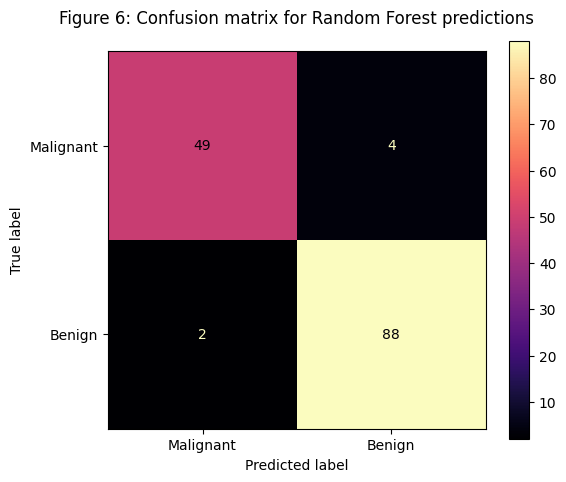

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[target_names_title[0], target_names_title[1]],
    ax=ax,
    cmap="magma"
)
ax.set_title("Figure 6: Confusion matrix for Random Forest predictions", pad=20)
plt.tight_layout()
plt.show()







## Figure 7: ROC curve

The ROC curve shows the trade-off between true positive rate and false positive rate across classification thresholds. A larger AUC means the model separates the two classes better.


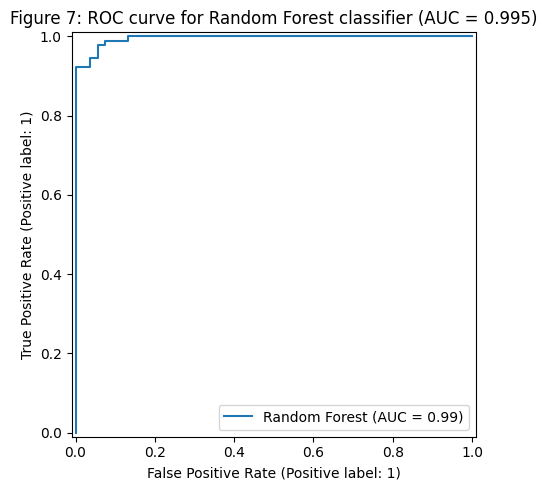

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest"
)
ax.set_title(f"Figure 7: ROC curve for Random Forest classifier (AUC = {auc_score:.3f})")
plt.tight_layout()
plt.show()

## Figure 8: Top 10 impurity-based feature importances

Random Forests can estimate feature importance based on how much each feature decreases impurity across the trees. This is easy to compute, but it can be biased when features are correlated or have many possible split points.


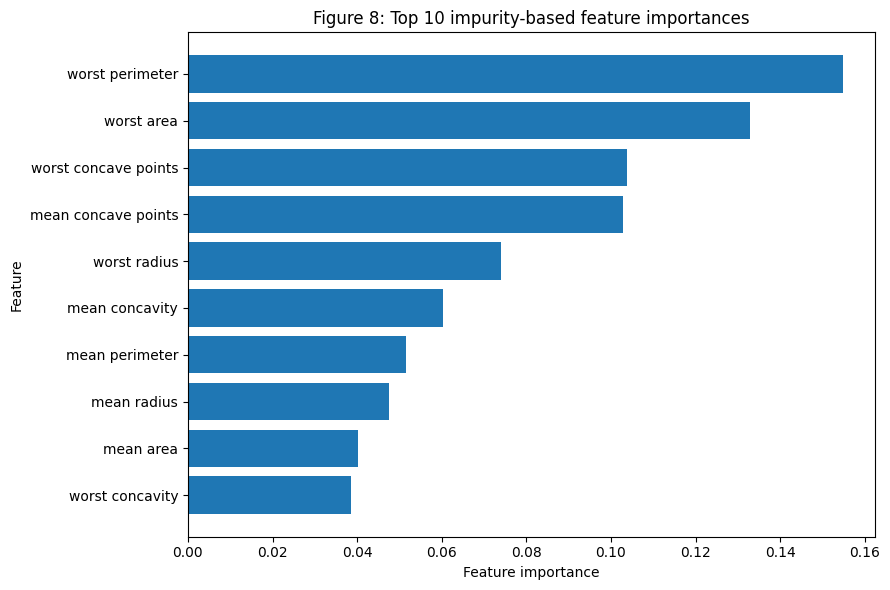

,feature,importance
22,worst perimeter,0.154788
23,worst area,0.132803
27,worst concave points,0.103918
7,mean concave points,0.102802
20,worst radius,0.074131
6,mean concavity,0.060324
2,mean perimeter,0.051658
0,mean radius,0.047452
3,mean area,0.040155
26,worst concavity,0.038636


In [28]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

top10_importance = importance_df.head(10).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10_importance["feature"], top10_importance["importance"])
ax.set_title("Figure 8: Top 10 impurity-based feature importances")
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.head(10)

## Figure 9: Permutation importance chart

Permutation importance measures how much model performance drops when one feature is randomly shuffled. If shuffling a feature hurts performance a lot, the model depended strongly on that feature.

This method is often easier to explain than impurity-based importance because it asks a direct question: **What happens to model performance when this feature is no longer useful?**


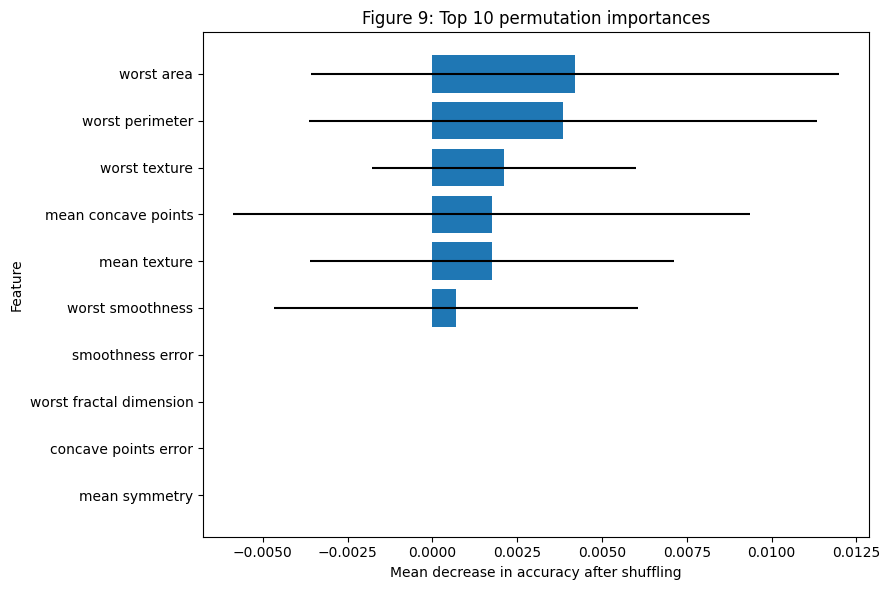

,feature,importance_mean,importance_std
23,worst area,0.004196,0.007787
22,worst perimeter,0.003846,0.007491
21,worst texture,0.002098,0.003894
1,mean texture,0.001748,0.005360
7,mean concave points,0.001748,0.007620
24,worst smoothness,0.000699,0.005371
8,mean symmetry,0.000000,0.000000
17,concave points error,0.000000,0.000000
14,smoothness error,0.000000,0.000000
29,worst fractal dimension,0.000000,0.000000


In [29]:
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

top10_perm = perm_df.head(10).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10_perm["feature"], top10_perm["importance_mean"], xerr=top10_perm["importance_std"])
ax.set_title("Figure 9: Top 10 permutation importances")
ax.set_xlabel("Mean decrease in accuracy after shuffling")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

perm_df.head(10)

## 6. How to reuse this workflow

To apply this tutorial to another classification dataset, replace the dataset-loading section and keep the rest of the workflow:

1. Put your predictors into `X`.
2. Put your class labels into `y`.
3. Split the data using `train_test_split`.
4. Train `RandomForestClassifier`.
5. Evaluate predictions using a confusion matrix and ROC curve.
6. Use feature importance to explain which variables the model relied on.

## Key takeaway

A Random Forest is useful because it combines many decision trees to make more stable predictions than a single tree. Feature importance then helps communicate which variables were most useful to the model, but the results should be interpreted carefully, especially when features are correlated.

## References

- Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
- scikit-learn documentation: `RandomForestClassifier`
- scikit-learn documentation: `load_breast_cancer`
- scikit-learn documentation: permutation feature importance
- scikit-learn documentation: ROC/AUC metrics
